In [1]:
num_particles = 100
run_time_days = 20
time_step_minutes = 5
out_put_step_hours = 6

#initial position
lon0 = -50
lon1 = -48
lat0 = 1
lat1 = -0.5

depth_min = 1 #todo: figure near-surface depths 
depth_max = 10

offset = 200
ref_date = "1993-01-01"
#reproducibility
rdm_seed = 999

#paths
pathUVW= '/work/bk1450/b383184/Amazon/Atlantic/data/reanalysis'
# pathW= '/work/bk1450/b383184/Amazon/Atlantic/data/W'


In [2]:
import numpy as np

In [3]:
out_path = f'../data/tracks_{rdm_seed}/' #path to store the particle zarr

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
start_time

np.datetime64('1993-07-20')

## Particles from the Plume to the Atlantic

* Release particles from the plume every month (1st day) for 4 years (2022-2025)
* Release time 2022 to 2025
* Number of particles =  100_000
* Release depth = (0,10)
* Compare the Wc and W

In [4]:
from parcels import ParticleSet
from parcels import JITParticle
from parcels import AdvectionRK4_3D
from parcels import AdvectionRK4
from parcels import Variable
from datetime import timedelta
import numpy as np
from parcels import FieldSet
from glob import glob

In [5]:
np.random.seed(rdm_seed)

### Copernicus Data C grid

In [6]:
ufiles = sorted(glob(f"{pathUVW}/U_19*.nc"))
vfiles = sorted(glob(f"{pathUVW}/V_19*.nc"))
wfiles = sorted(glob(f"{pathUVW}/W_19*.nc"))

In [7]:
print(f"Found {len(ufiles)} U files, {len(vfiles)} V files, {len(wfiles)} W files")

Found 84 U files, 84 V files, 84 W files


In [8]:
print(ufiles[:3])

['/work/bk1450/b383184/Amazon/Atlantic/data/reanalysis/U_1993-01.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/reanalysis/U_1993-02.nc', '/work/bk1450/b383184/Amazon/Atlantic/data/reanalysis/U_1993-03.nc']


In [9]:
## define the fieldset
filenames = {"U": ufiles,
             "V": vfiles,
             "W": wfiles,
            }

variables = {
    "U": "uf",
    "V": "vf",
    "W": "w_c",
}

interp_method = {
    "U":"cgrid_velocity",
    "V":"cgrid_velocity",
    "W":"cgrid_velocity",
}

dimensions = {
    "U": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "V": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"},
    "W": {"lon": "longitude_f", "lat": "latitude_f", "depth": "depth_w", "time": "time"}
}


## now the fieldset
fieldset = FieldSet.from_netcdf(
    filenames, 
    variables, 
    dimensions,
    interp_method = interp_method,
    deferred_load=True,
    allow_time_extrapolation = False,
    gridindexingtype = "nemo",
)

In [10]:
start_pos_along_line = np.random.uniform(0,1,size=num_particles)
start_lon = lon0 + start_pos_along_line * (lon1-lon0)
start_lat = lat0 + start_pos_along_line * (lat1-lat0)
start_depth = np.random.uniform(depth_min,depth_max,size=num_particles)
start_times = np.datetime64(start_time)

In [11]:
# initiate pset
pset = ParticleSet(
    fieldset=fieldset,
    lon = start_lon,
    lat = start_lat,
    depth=start_depth,
    time=start_times
) 


out_fn = f'Parcels_run_{rdm_seed}_{start_time}.zarr'

output_file = pset.ParticleFile(
    name=out_path+out_fn,
    outputdt=timedelta(hours=out_put_step_hours),
    chunks = (num_particles,int(run_time_days*24/out_put_step_hours/4))
)

In [12]:
##check the error
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

In [13]:
## Execute particles
pset.execute(
    [AdvectionRK4_3D,CheckError],
    runtime=timedelta(days=run_time_days),
    dt=timedelta(minutes=time_step_minutes),
    output_file= output_file
)

INFO: Output files are stored in ../data/tracks_999/Parcels_run_999_1993-07-20.zarr.
100%|██████████| 1728000.0/1728000.0 [03:57<00:00, 7267.51it/s] 


### Plotting

In [14]:
import xarray as xr
import matplotlib.pyplot as plt

In [15]:
out_path = f'../data/tracks_{rdm_seed}/'
# out_fn = 'Parcels_run_692' 

ds_traj = xr.open_zarr(out_path+out_fn)
# ds_traj = ds_traj.compute()
ds_traj

<xarray.Dataset> Size: 257kB
Dimensions:     (trajectory: 100, obs: 80)
Coordinates:
  * obs         (obs) int32 320B 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79
  * trajectory  (trajectory) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
Data variables:
    lat         (trajectory, obs) float64 64kB dask.array<chunksize=(100, 20), meta=np.ndarray>
    lon         (trajectory, obs) float64 64kB dask.array<chunksize=(100, 20), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 64kB dask.array<chunksize=(100, 20), meta=np.ndarray>
    z           (trajectory, obs) float64 64kB dask.array<chunksize=(100, 20), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

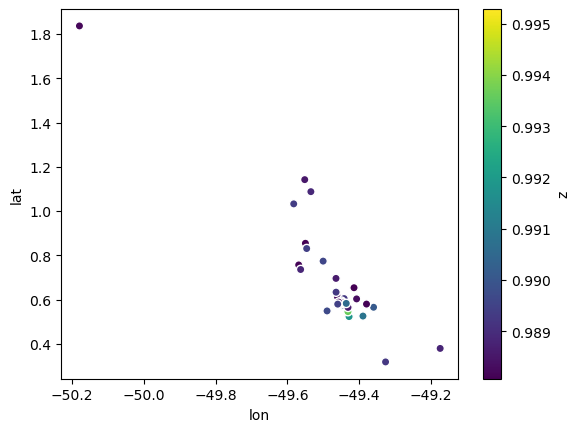

In [16]:
last_valid = ds_traj.lat.notnull().astype(int).diff('obs',label='lower')==-1
ds_traj.where(last_valid).mean('obs').compute().plot.scatter(x='lon',y='lat',hue='z')

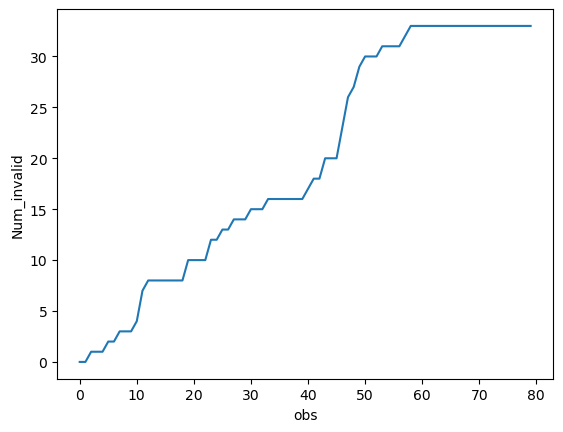

In [17]:
ds_traj.lat.isnull().sum('trajectory').rename('Num_invalid').plot()
plt.show()

In [31]:
# (ds.lat.isnull().sum('trajectory').rename('Num_invalid').compute().max().item() / int(ds.sizes.get("trajectory")))*100

33.0

In [29]:
final_nan = ds_traj.lat.isnull().isel(obs=-1)
print(final_nan)
# Force computation before calling .item()
lost = int(final_nan.sum().compute().item())
print(lost)

total = int(ds_traj.sizes.get("trajectory"))
print(total)

pct = 100.0 * lost / total if total else np.nan
print(pct)

<xarray.DataArray 'lat' (trajectory: 100)> Size: 100B
dask.array<getitem, shape=(100,), dtype=bool, chunksize=(100,), chunktype=numpy.ndarray>
Coordinates:
    obs         int32 4B 79
  * trajectory  (trajectory) int64 800B 0 1 2 3 4 5 6 7 ... 93 94 95 96 97 98 99
33
100
33.0
